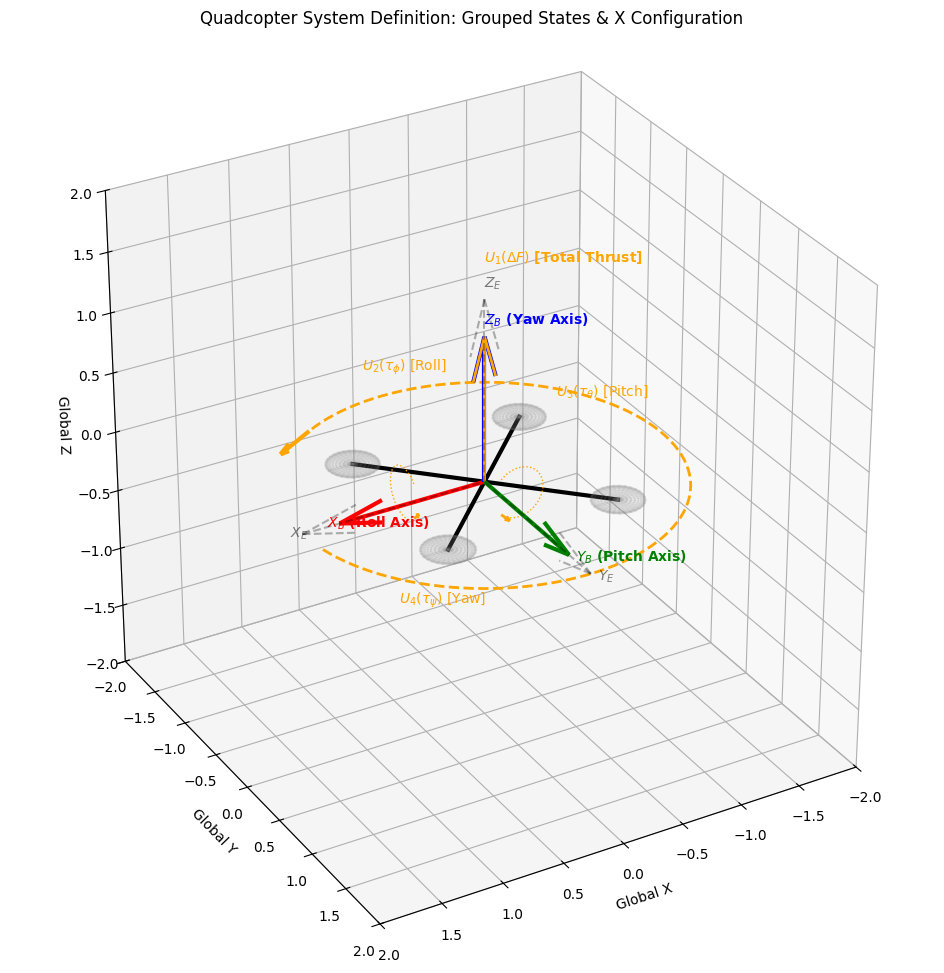

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches

# --- CONFIGURATION ---
L = 1.0  # Arm length parameter (scales the drawing)
rotor_radius = 0.2
fig_size = (14, 12)
view_angle = (30, 60) # Elevation, Azimuth

# --- SETUP PLOT ---
fig = plt.figure(figsize=fig_size)
ax = fig.add_subplot(111, projection='3d')
ax.set_aspect('equal')

# --- 1. DRAW INERTIAL FRAME {E} ---
# Lighter, dashed lines starting from the origin
origin = np.array([0, 0, 0])
ax.quiver(0, 0, 0, 1, 0, 0, color='black', alpha=0.3, linestyle='dashed', length=L*1.5)
ax.quiver(0, 0, 0, 0, 1, 0, color='black', alpha=0.3, linestyle='dashed', length=L*1.5)
ax.quiver(0, 0, 0, 0, 0, 1, color='black', alpha=0.3, linestyle='dashed', length=L*1.5)
ax.text(L*1.6, 0, 0, r'$X_E$', color='black', alpha=0.5, weight='bold')
ax.text(0, L*1.6, 0, r'$Y_E$', color='black', alpha=0.5, weight='bold')
ax.text(0, 0, L*1.6, r'$Z_E$', color='black', alpha=0.5, weight='bold')

# --- 2. DRAW DRONE STRUCTURE ('X' Config) ---
# Calculate rotor positions (45 degrees offset from body axes)
theta = np.deg2rad(np.array([45, 135, 225, 315]))
x_rotors = L * np.cos(theta)
y_rotors = L * np.sin(theta)
z_rotor = 0.0

# Draw Arms
ax.plot([x_rotors[0], x_rotors[2]], [y_rotors[0], y_rotors[2]], [0, 0], 'black', linewidth=3)
ax.plot([x_rotors[1], x_rotors[3]], [y_rotors[1], y_rotors[3]], [0, 0], 'black', linewidth=3)

# Draw generic rotor disks (programmatic placeholders)
for i in range(4):
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 20)
    x = rotor_radius * np.outer(np.cos(u), np.sin(v)) + x_rotors[i]
    y = rotor_radius * np.outer(np.sin(u), np.sin(v)) + y_rotors[i]
    z = 0.0 * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x, y, z, color='gray', alpha=0.1)

# --- 3. DRAW BODY FRAME {B} (Solid, Colors) ---
# X-body is red (points forward, between motors)
# Y-body is green (points left, between motors)
# Z-body is blue (points up)
ax.quiver(0, 0, 0, 1, 0, 0, color='red', linewidth=3, length=L*1.2)
ax.quiver(0, 0, 0, 0, 1, 0, color='green', linewidth=3, length=L*1.2)
ax.quiver(0, 0, 0, 0, 0, 1, color='blue', linewidth=3, length=L*1.2)
ax.text(L*1.3, 0, 0, r'$X_B$ (Roll Axis)', color='red', weight='bold')
ax.text(0, L*1.3, 0, r'$Y_B$ (Pitch Axis)', color='green', weight='bold')
ax.text(0, 0, L*1.3, r'$Z_B$ (Yaw Axis)', color='blue', weight='bold')

# --- 4. DRAW VIRTUAL CONTROL INPUTS (U1, U2, U3, U4) ---
# These schematic arrows visualize the torques and thrust generated by the MPC.

# Total Thrust (U1 / Delta F) - Big arrow pushing up Z_B
ax.quiver(0, 0, 0, 0, 0, 1.5, color='orange', linewidth=2, length=L*0.8, arrow_length_ratio=0.3)
ax.text(0, 0, L*1.8, r'$U_1 (\Delta F)$ [Total Thrust]', color='orange', weight='bold', size=10)

# Roll Torque (U2 / tau_phi) - Curved arrow around X_B
t_circ = np.linspace(np.deg2rad(45), np.deg2rad(315), 50)
r_circ = L*0.2
y_circ = r_circ * np.cos(t_circ) + L*0.6 # Offset slightly along the axis
z_circ = r_circ * np.sin(t_circ) + L*0.5 # Offset slightly along the axis
ax.plot(np.ones(50)*L*1.0, y_circ, z_circ, color='orange', linestyle='dotted', linewidth=1)
ax.quiver(L*1.0, y_circ[-1], z_circ[-1], 0, -np.sin(t_circ[-1]), np.cos(t_circ[-1]), color='orange', length=0.1, linewidth=2, arrow_length_ratio=0.5)
ax.text(L*1.0, 0, L*1.2, r'$U_2 (\tau_\phi)$ [Roll]', color='orange')

# Pitch Torque (U3 / tau_theta) - Curved arrow around Y_B
r_circ = L*0.2
x_circ = r_circ * np.cos(t_circ) + L*0.3
z_circ = r_circ * np.sin(t_circ) + L*0.5
ax.plot(x_circ, np.ones(50)*L*1.0, z_circ, color='orange', linestyle='dotted', linewidth=1)
ax.quiver(x_circ[-1], L*1.0, z_circ[-1], np.sin(t_circ[-1]), 0, -np.cos(t_circ[-1]), color='orange', length=0.1, linewidth=2, arrow_length_ratio=0.5)
ax.text(0, L*1.0, L*1.2, r'$U_3 (\tau_\theta)$ [Pitch]', color='orange')

# Yaw Torque (U4 / tau_psi) - Curved arrow around Z_B
t_circ_yaw = np.linspace(np.deg2rad(10), np.deg2rad(300), 100)
r_circ_yaw = L * 1.5
x_circ = r_circ_yaw * np.cos(t_circ_yaw)
y_circ = r_circ_yaw * np.sin(t_circ_yaw)
ax.plot(x_circ, y_circ, np.zeros_like(t_circ_yaw), color='orange', linestyle='dashed', linewidth=2)
ax.quiver(x_circ[-1], y_circ[-1], 0, -np.sin(t_circ_yaw[-1]), np.cos(t_circ_yaw[-1]), 0, color='orange', length=0.4, linewidth=3)
ax.text(L*1.6, L*1.6, 0.3, r'$U_4 (\tau_\psi)$ [Yaw]', color='orange')

# --- FINAL PLOT POLISHING ---
limit = L * 2.0
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)
ax.set_xlabel('Global X')
ax.set_ylabel('Global Y')
ax.set_zlabel('Global Z')
ax.view_init(elev=view_angle[0], azim=view_angle[1])
ax.set_title('Quadcopter System Definition: Grouped States & X Configuration')
plt.grid(False)
plt.savefig("quadcopter_x_config_frame.png", dpi=300, bbox_inches='tight')
plt.show()